# Train Linear Regression Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")


from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import average_precision_score, matthews_corrcoef

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Loading dataset

In [2]:
data_path = Path("/Users/eugene_kuj/PycharmProjects/DS_lab/data/merged_v5.csv")

df = pd.read_csv(data_path)

df.head()

,region_id,time,alarm,neighbor_alarms_count,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day
0,2,2022-03-28 00:00:00+03:00,0,0,0.4,-2.2,43.82,-10.5,0.0,0.0,0,7.6,314.0,1029.0,24.1,2.0,0.0,0,13,5,0,0,4,4,0,0,0,0,0,0,5,5,5,4,0,86,289,-3,0,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
1,2,2022-03-28 01:00:00+03:00,0,0,-0.1,-2.5,45.43,-10.5,0.0,0.0,0,6.8,308.6,1029.0,24.1,4.2,0.0,0,8,2,0,0,3,3,0,0,0,0,0,0,1,1,1,4,0,45,285,-3,1,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
2,2,2022-03-28 02:00:00+03:00,0,0,-0.6,-2.3,47.87,-10.3,0.0,0.0,0,5.0,305.7,1029.0,24.1,3.1,0.0,0,7,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,28,269,-2,2,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
3,2,2022-03-28 03:00:00+03:00,0,0,-1.1,-1.1,51.24,-9.9,0.0,0.0,0,4.0,289.8,1029.0,24.1,1.8,0.0,0,11,10,0,0,0,0,2,0,2,0,0,0,9,9,9,0,2,26,275,10,3,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
4,2,2022-03-28 04:00:00+03:00,0,0,-1.4,-1.4,52.80,-9.8,0.0,0.0,0,3.6,245.2,1029.0,24.1,0.0,0.0,0,9,1,0,0,6,6,2,0,2,0,0,0,1,1,2,6,2,27,283,-9,4,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 734233 entries, 0 to 734232
Data columns (total 69 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   region_id                  734233 non-null  int64  
 1   time                       734233 non-null  str    
 2   alarm                      734233 non-null  int64  
 3   neighbor_alarms_count      734233 non-null  int64  
 4   hour_temp                  734233 non-null  float64
 5   hour_feelslike             734233 non-null  float64
 6   hour_humidity              734233 non-null  float64
 7   hour_dew                   734233 non-null  float64
 8   hour_precip                734233 non-null  float64
 9   hour_precipprob            734233 non-null  float64
 10  hour_preciptype            734233 non-null  int64  
 11  hour_windspeed             734233 non-null  float64
 12  hour_winddir               734233 non-null  float64
 13  hour_pressure              734233 non-nu

# Time feature engineering


In [4]:
df["time"] = pd.to_datetime(df["time"], utc=True)

df["year"] = df["time"].dt.year.astype(int)
df["month"] = df["time"].dt.month.astype(int)
df["day"] = df["time"].dt.day.astype(int)

df.head()

,region_id,time,alarm,neighbor_alarms_count,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day
0,2,2022-03-27 21:00:00+00:00,0,0,0.4,-2.2,43.82,-10.5,0.0,0.0,0,7.6,314.0,1029.0,24.1,2.0,0.0,0,13,5,0,0,4,4,0,0,0,0,0,0,5,5,5,4,0,86,289,-3,0,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,27
1,2,2022-03-27 22:00:00+00:00,0,0,-0.1,-2.5,45.43,-10.5,0.0,0.0,0,6.8,308.6,1029.0,24.1,4.2,0.0,0,8,2,0,0,3,3,0,0,0,0,0,0,1,1,1,4,0,45,285,-3,1,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,27
2,2,2022-03-27 23:00:00+00:00,0,0,-0.6,-2.3,47.87,-10.3,0.0,0.0,0,5.0,305.7,1029.0,24.1,3.1,0.0,0,7,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,28,269,-2,2,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,27
3,2,2022-03-28 00:00:00+00:00,0,0,-1.1,-1.1,51.24,-9.9,0.0,0.0,0,4.0,289.8,1029.0,24.1,1.8,0.0,0,11,10,0,0,0,0,2,0,2,0,0,0,9,9,9,0,2,26,275,10,3,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
4,2,2022-03-28 01:00:00+00:00,0,0,-1.4,-1.4,52.80,-9.8,0.0,0.0,0,3.6,245.2,1029.0,24.1,0.0,0.0,0,9,1,0,0,6,6,2,0,2,0,0,0,1,1,2,6,2,27,283,-9,4,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28


In [5]:
print(f"Percent of alarms: {df["alarm"].sum() / len(df):.2%}")

Percent of alarms: 22.32%


# Target and features

In [6]:
target = "alarm"

features = [c for c in df.columns if c not in ["alarm", "time"]]#["alarm","time"]]

X = df[features]
y = df[target]

print("Number of features:", len(features))

Number of features: 67


# Feature groups

In [7]:
cat_cols = [
    "hour_preciptype",
    "hour_conditions",
    "is_weekend"
]

num_cols = [
    col for col in X.columns
    if col not in cat_cols
]

print("Numeric:", len(num_cols))
print("Categorical:", len(cat_cols))

Numeric: 64
Categorical: 3


# Preprocessing pipeline
Numeric features are scaled using StandardScaler.
Categorical features pass through unchanged.

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", cat_cols)
    ]
)

In [9]:
model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", LinearRegression())
])

In [10]:
tss = TimeSeriesSplit(n_splits=5, gap=24*7)

unique_hours = df["time"].sort_values().unique()

In [28]:
results = []
models = []

for fold, (train_idx, test_idx) in enumerate(tss.split(unique_hours)):
    
    train_hours = unique_hours[train_idx]
    test_hours = unique_hours[test_idx]

    train_df = df[df["time"].isin(train_hours)]
    test_df = df[df["time"].isin(test_hours)]

    X_train = train_df[features]
    y_train = train_df[target]

    X_test = test_df[features]
    y_test = test_df[target]

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    preds_class = (preds >= 0.5).astype(int)
    y_test_class = (y_test > 0).astype(int)

    auprc = average_precision_score(y_test_class, preds)
    mcc = matthews_corrcoef(y_test_class, preds_class)

    results.append({
        "fold": fold,
        "auprc": auprc,
        "mcc": mcc
    })

    models.append(model)

    print(f"Fold {fold}")
    print("AUPRC:", round(auprc,3))
    print("MCC:", round(mcc,3))
    print("-" * 40)

Fold 0
AUPRC: 0.861
MCC: 0.774
----------------------------------------
Fold 1
AUPRC: 0.867
MCC: 0.687
----------------------------------------
Fold 2
AUPRC: 0.89
MCC: 0.708
----------------------------------------
Fold 3
AUPRC: 0.911
MCC: 0.733
----------------------------------------
Fold 4
AUPRC: 0.935
MCC: 0.674
----------------------------------------


In [29]:
results_df = pd.DataFrame(results)

results_df

,fold,auprc,mcc
0,0,0.860519,0.774239
1,1,0.867255,0.686835
2,2,0.889588,0.708346
3,3,0.911445,0.732551
4,4,0.934917,0.673698


In [30]:
results_df.mean()

fold     2.000000
auprc    0.892745
mcc      0.715134
dtype: float64

# Evaluate

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "regressor__fit_intercept": [True, False],
    "regressor__positive": [True, False]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

Best parameters: {'regressor__fit_intercept': True, 'regressor__positive': True}


In [32]:
best_model = grid.best_estimator_

In [33]:
print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'regressor__fit_intercept': True, 'regressor__positive': True}
Best CV score: -0.0756094744234072


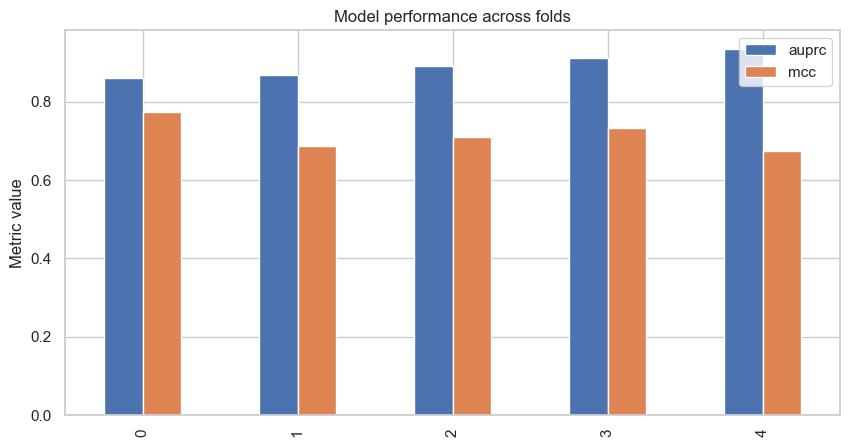

In [34]:
metrics_cols = ["auprc","mcc"]

results_df[metrics_cols].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model performance across folds")
plt.ylabel("Metric value")

plt.show()

# Confusion Matrix explanation

Confusion matrix shows the number of correct and incorrect predictions.

TP (True Positive) – model correctly predicts alarm.

TN (True Negative) – model correctly predicts no alarm.

FP (False Positive) – model predicts alarm but there is none.

FN (False Negative) – model misses an alarm.

These values help understand what type of mistakes the model makes.

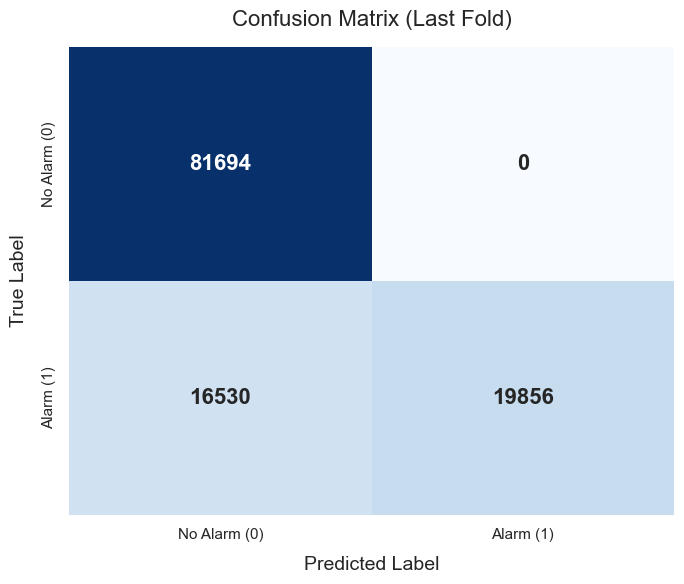

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test_class, preds_class)

plt.figure(figsize=(7, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                 annot_kws={'size': 16, 'weight': 'bold'},
                 xticklabels=['No Alarm (0)', 'Alarm (1)'],
                 yticklabels=['No Alarm (0)', 'Alarm (1)'])

plt.title('Confusion Matrix (Last Fold)', fontsize=16, pad=15)
plt.xlabel('Predicted Label', fontsize=14, labelpad=10)
plt.ylabel('True Label', fontsize=14, labelpad=10)

ax.grid(False) 
plt.tight_layout()
plt.show()

# Top 20 features and weights

In [19]:
feature_names = num_cols + cat_cols

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": coefficients
})

coef_df["abs_weight"] = coef_df["weight"].abs()

top20 = coef_df.sort_values("abs_weight", ascending=False).head(20)

top20

,feature,weight,abs_weight
1,neighbor_alarms_count,0.291484,0.291484
27,nlp_повітряна_тривога,-0.044995,0.044995
26,nlp_повітряна,0.038047,0.038047
20,nlp_дніпропетровська,0.018555,0.018555
17,nlp_бпла,0.017124,0.017124
25,nlp_нікопольська,-0.015965,0.015965
30,nlp_харківська,0.014385,0.014385
5,hour_dew,0.014312,0.014312
61,year,0.012623,0.012623
19,nlp_відбій_тривоги,-0.011739,0.011739


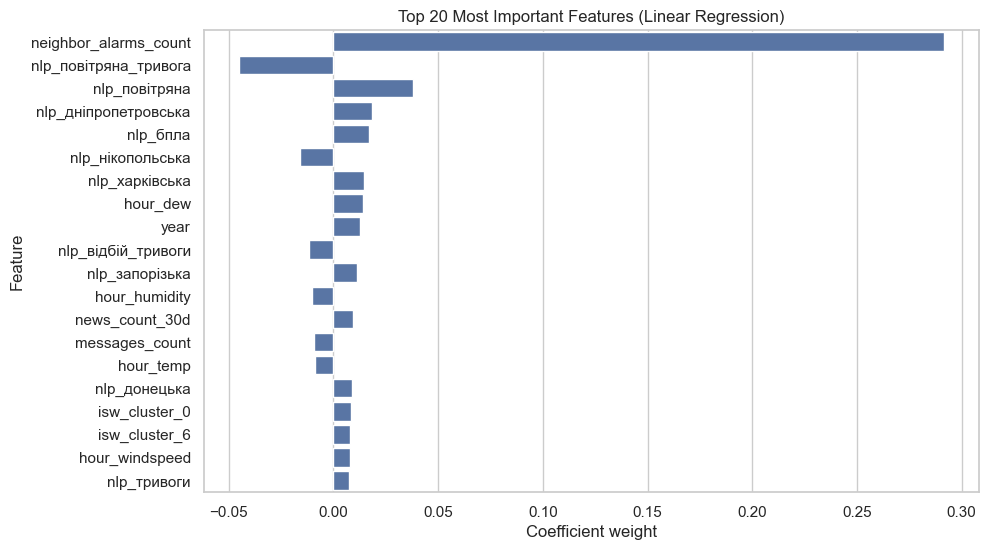

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top20,
    x="weight",
    y="feature"
)

plt.title("Top 20 Most Important Features (Linear Regression)")
plt.xlabel("Coefficient weight")
plt.ylabel("Feature")

plt.show()

# Report

# Task 4. Train Models
- A Linear Regression model was trained using the processed dataset. Feature engineering was performed by extracting temporal variables (year, month, and day) from the timestamp column.
- A preprocessing and modeling workflow was implemented using a scikit-learn pipeline. - Cross-validation was applied to ensure reliable model evaluation and reduce the risk of overfitting.
- Hyperparameter tuning was performed using GridSearchCV. The best parameters obtained were:
  - fit_intercept = True
  - positive = False
These parameters allow the model to include an intercept term and use both positive and negative feature coefficients.

# Task 5. Evaluate Models
- The trained model was evaluated using several performance metrics, including AUPRC, and MCC.
- A confusion matrix was also calculated to analyze classification performance derived from the model’s predictions. The confusion matrix provides information about true positives, true negatives, false positives, and false negatives, allowing a detailed assessment of prediction errors.
- Additionally, feature importance was analyzed using the coefficients of the Linear Regression model. The top 20 most influential features were visualized to better interpret the model’s behavior.

# Hardest Part of the Work
The most challenging part of the project was constructing the machine learning pipeline and integrating preprocessing, model training, and evaluation into a consistent workflow. Another difficulty was selecting and interpreting appropriate evaluation metrics such as AUPRC and MCC, which required additional research and careful interpretation.

In [21]:
df.time.max

<bound method Series.max of 0        2022-03-27 21:00:00+00:00
1        2022-03-27 22:00:00+00:00
2        2022-03-27 23:00:00+00:00
3        2022-03-28 00:00:00+00:00
4        2022-03-28 01:00:00+00:00
                    ...           
734228   2026-03-11 12:00:00+00:00
734229   2026-03-11 13:00:00+00:00
734230   2026-03-11 14:00:00+00:00
734231   2026-03-11 15:00:00+00:00
734232   2026-03-11 16:00:00+00:00
Name: time, Length: 734233, dtype: datetime64[us, UTC]>